# Plücker Ray로 360° ERP Panorama → 일반 Perspective Image

360° equirectangular panorama (ERP)를 입력으로 받아
일반 pinhole perspective image를 생성하는 예제입니다.

핵심 흐름은 다음과 같습니다.
Perspective pixel → camera ray → world ray → plücker ray → ERP coordinate → sampling


중요한 점은 **Plücker ray 자체가 panorama를 펼치는 연산은 아니라는 것**입니다.
ERP → perspective 변환에서 실제 sampling에 필요한 것은 ray direction $d$이고,
Plücker representation $e=(m,d)$는 ray의 방향뿐 아니라 공간적 위치도 함께 표현합니다.

## 1. Imports

HW1.zip 에 있는 panorama image를 경로에 맞춰 입력하세요

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# panorama image를 경로에 맞게 넣어주세요
PANORAMA_PATH = "C:/Users/super/FundamentalCV_HW/HW1.png"

## 2. ERP panorama 준비

ERP shape: (887, 1774, 3)


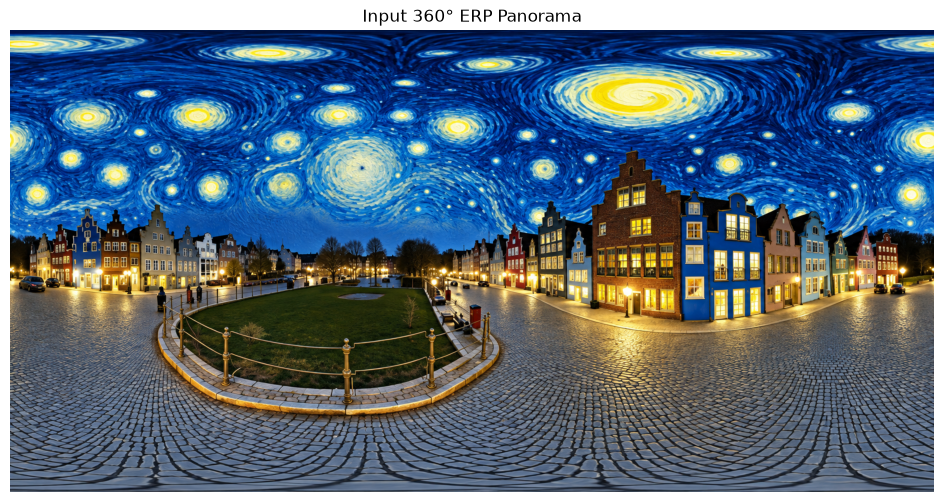

In [3]:
def make_test_erp(width=1024, height=512):
    u = np.linspace(0.0, 1.0, width, endpoint=False)
    v = np.linspace(0.0, 1.0, height, endpoint=False)
    uu, vv = np.meshgrid(u, v)

    r = uu
    g = 1.0 - vv
    b = 0.5 + 0.5 * np.sin(8 * np.pi * uu) * np.cos(4 * np.pi * vv)

    img = np.stack([r, g, np.clip(b, 0, 1)], axis=-1)

    # seam과 방향을 쉽게 보기 위한 grid
    grid_x = np.mod(np.arange(width), max(1, width // 12)) < 3
    grid_y = np.mod(np.arange(height), max(1, height // 6)) < 3
    grid = grid_y[:, None] | grid_x[None, :]
    img[grid] = 1.0

    return img.astype(np.float32)

if PANORAMA_PATH is None:
    pano = make_test_erp()
    print("Synthetic ERP panorama 사용")
else:
    pano = np.asarray(Image.open(PANORAMA_PATH).convert("RGB"), dtype=np.float32) / 255.0

H_erp, W_erp = pano.shape[:2]
print("ERP shape:", pano.shape)

plt.figure(figsize=(14, 6))
plt.imshow(pano)
plt.title("Input 360° ERP Panorama")
plt.axis("off")
plt.show()

## 3. Perspective pixel → camera ray

출력 이미지의 각 pixel에 대해 pinhole camera ray를 만듭니다.

좌표계:
- $+x$: right
- $+y$: up
- $+z$: forward


In [4]:
def perspective_camera_rays(out_w, out_h, fov_deg):
    fov = np.deg2rad(fov_deg)
    #fov_deg denotes the horizontal field of view. The vertical field of view is determined by the output aspect ratio.
    fx = (out_w / 2.0) / np.tan(fov / 2.0)
    fy = fx

    cx = (out_w - 1) / 2.0
    cy = (out_h - 1) / 2.0

    u, v = np.meshgrid(np.arange(out_w), np.arange(out_h))

    x = (u - cx) / fx
    y = -(v - cy) / fy
    z = np.ones_like(x)

    d = np.stack([x, y, z], axis=-1)
    d /= np.linalg.norm(d, axis=-1, keepdims=True)

    return d

## 4. Yaw / Pitch / Roll rotation
Rotation convention used in this assignment:

+x : right
+y : up
+z : forward

positive yaw   : look right
positive pitch : look up
positive roll  : right-handed rotation about +z

For column-vector notation, use

R = Ry(yaw) @ Rx(-pitch) @ Rz(roll)

Rays are stored as row vectors in the implementation, so
rotate_rays uses rays @ R.T.

In [6]:
def Rx(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1,0,0],[0,c,-s],[0,s,c]], dtype=np.float32)

def Ry(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c,0,s],[0,1,0],[-s,0,c]], dtype=np.float32)

def Rz(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c,-s,0],[s,c,0],[0,0,1]], dtype=np.float32)

def rotation_matrix(yaw_deg=0, pitch_deg=0, roll_deg=0):
    yaw   = np.deg2rad(yaw_deg)
    pitch = np.deg2rad(pitch_deg)
    roll  = np.deg2rad(roll_deg)

    # Prob.1: 지정된 회전 순서를 만족하는 3x3 회전행렬을 구성하시오.
    # 구현 후 R @ R.T가 단위행렬인지 수치적으로 확인할 수 있어야 한다.
    return Ry(yaw) @ Rx(-pitch) @ Rz(roll)

def rotate_rays(rays, R):
    return rays @ R.T

# Sanity checks
R = rotation_matrix(yaw_deg=90)
center = np.array([0.0, 0.0, 1.0])
assert np.allclose(R @ center, [1.0, 0.0, 0.0], atol=1e-6)

R = rotation_matrix(pitch_deg=30)
up_ray = R @ center

# positive pitch must look upward
assert up_ray[1] > 0

R = rotation_matrix(20, 10, 5)
assert np.allclose(R @ R.T, np.eye(3), atol=1e-6)

## 5. Plücker ray

Plücker representation:

$$
e=(m,d), \qquad m=o\times d
$$

- $d$: ray direction
- $o$: camera origin
- $m$: moment

같은 방향을 보는 평행한 ray라도 origin이 다르면 $m$이 달라집니다.

단, single panorama는 기본적으로 한 camera center에서 관측된 environment map이므로,  
**translation에 따른 parallax는 depth 또는 explicit 3D representation 없이 만들 수 없습니다.**

In [7]:
def plucker_rays(ray_directions, camera_origin=(0.0, 0.0, 0.0)):
    # Prob.2: ray direction 정규화, origin broadcasting, moment 계산,
    # [m, d] 순서의 6차원 Plücker tensor 구성을 모두 구현하시오.

    # 각 ray의 방향을 길이가 1인 벡터로 정규화
    d = np.asarray(ray_directions, dtype=np.float32)
    d = d / np.linalg.norm(d, axis=-1, keepdims=True)

    # 카메라 원점을 모든 ray에 맞는 크기로 확장
    o = np.asarray(camera_origin, dtype=np.float32)
    o = np.broadcast_to(o, d.shape)

    # moment 계산 : m = o × d
    m = np.cross(o, d)

    # [m, d] 순서로 연결
    e = np.concatenate([m, d], axis=-1)

    return e, m, d

## 6. Ray direction → ERP coordinate

$$
\theta = \operatorname{atan2}(d_x, d_z)
$$

$$
\phi = \arcsin(d_y)
$$

그리고

$$
u = \left(\frac{\theta}{2\pi} + \frac{1}{2}\right) W
$$

$$
v = \left(\frac{1}{2} - \frac{\phi}{\pi}\right) H
$$

로 ERP pixel coordinate를 얻습니다.

In [8]:
def direction_to_erp_uv(d, erp_w, erp_h):
    x = d[..., 0]
    y = np.clip(d[..., 1], -1.0, 1.0)
    z = d[..., 2]

    theta = np.arctan2(x, z)
    phi = np.arcsin(y)

    u = (theta / (2.0 * np.pi) + 0.5) * erp_w
    v = (0.5 - phi / np.pi) * erp_h

    return u, v

## 7. Bilinear sampling

$u_0=\lfloor u\rfloor$, $v_0=\lfloor v\rfloor$, 
$\delta_u=u-u_0$, $\delta_v=v-v_0$라 하면

$$
I(u,v)
=
(1-\delta_v)
\left[
(1-\delta_u)I_{00}
+
\delta_u I_{10}
\right]
+
\delta_v
\left[
(1-\delta_u)I_{01}
+
\delta_u I_{11}
\right].
$$

ERP의 좌우는 연결되어 있으므로 가로좌표에는 순환 경계조건을 사용합니다.

In [ ]:
def bilinear_sample_erp(img, u, v):
    h, w = img.shape[:2]

    u = np.mod(u, w)
    v = np.clip(v, 0, h - 1)

    # Prob.3: 주변 네 pixel 선택부터 가로/세로 보간까지 bilinear sampling을 구현하시오.
    # ERP seam이 이어지도록 가로 index에는 순환 경계조건을 사용해야 한다.
    
    # 주변 4개의 픽셀 좌표
    u0 = np.floor(u).astype(np.int64)
    v0 = np.floor(v).astype(np.int64)

    u1 = (u0 + 1) % w   # 마지막 열의 다음 픽셀은 첫 번째 열
    v1 = np.minimum(v0 + 1, h - 1)

    # 소수 부분을 각 픽셀의 가중치로 사용
    du = (u - u0)[..., None]
    dv = (v - v0)[..., None]

    # 4개의 픽셀 RGB 값
    I00 = img[v0, u0]  # 왼쪽 위
    I10 = img[v0, u1]  # 오른쪽 위
    I01 = img[v1, u0]  # 왼쪽 아래
    I11 = img[v1, u1]  # 오른쪽 아래

    # 각 행에서 가로 방향으로 가중 평균 계산
    top = (1 - du) * I00 + du * I10
    bottom = (1 - du) * I01 + du * I11

    # 두 행 사이를 세로 방향으로 가중 평균 계산
    return (1 - dv) * top + dv * bottom

## 8. 전체 ERP → Perspective 함수

In [ ]:
## 8. 전체 ERP → Perspective 함수

def erp_to_perspective(
    pano,
    out_w=640,
    out_h=480,
    fov_deg=90,
    yaw_deg=0,
    pitch_deg=0,
    roll_deg=0,
    camera_origin=(0.0, 0.0, 0.0),
):
    # Prob.4:
    # 앞에서 구현할 함수들을 이용하여
    # pixel -> camera ray
    #       -> world ray
    #       -> Plucker ray
    #       -> ERP coordinate
    #       -> bilinear sampling
    
    # 출력 이미지의 각 픽셀에 대한 카메라 ray를 생성
    camera_rays = perspective_camera_rays(out_w, out_h, fov_deg)

    # 회전 행렬을 적용해서 world ray로 변환
    R = rotation_matrix(yaw_deg, pitch_deg, roll_deg)
    world_rays = rotate_rays(camera_rays, R)

    # Plucker ray 구성
    e, m, d = plucker_rays(world_rays, camera_origin)

    # 방향 d를 입력 파노라마의 픽셀 좌표로 변환
    erp_h, erp_w = pano.shape[:2]
    u, v = direction_to_erp_uv(d, erp_w, erp_h)

    # 해당 좌표의 색을 bilinear sampling으로 가져오기
    perspective = bilinear_sample_erp(pano, u, v)

    return perspective, e, (u, v)

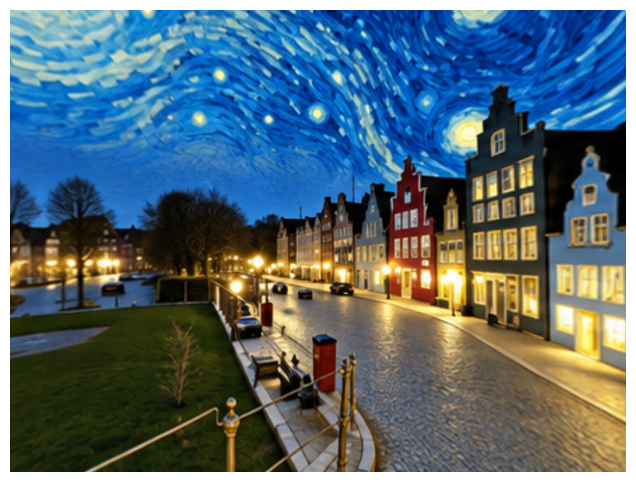

In [12]:
front, plucker, (u, v) = erp_to_perspective(
    pano,
    out_w=640,
    out_h=480,
    fov_deg=90,
    yaw_deg=0,
    pitch_deg=0,
)

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(front, 0, 1))
plt.axis("off")
plt.show()

## 9. 정면 perspective view

기본 origin이 $(0,0,0)$이므로 $m=o\times d=0$입니다. 중앙 pixel의 direction은 해상도에 따른 반 pixel 차이를 제외하면 $(0,0,1)$에 가깝습니다.

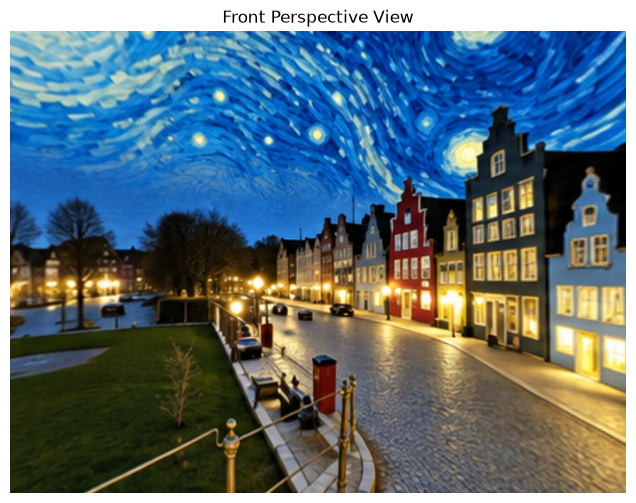

Plücker tensor shape: (480, 640, 6)
Center pixel [m_x,m_y,m_z,d_x,d_y,d_z]:
[ 0.          0.         -0.          0.0015625  -0.0015625   0.99999756]


In [13]:
front, plucker, (u, v) = erp_to_perspective(
    pano,
    out_w=640,
    out_h=480,
    fov_deg=90,
    yaw_deg=0,
    pitch_deg=0,
)

plt.figure(figsize=(8, 6))
plt.imshow(np.clip(front, 0, 1))
plt.title("Front Perspective View")
plt.axis("off")
plt.show()

print("Plücker tensor shape:", plucker.shape)
print("Center pixel [m_x,m_y,m_z,d_x,d_y,d_z]:")
print(plucker[480 // 2, 640 // 2])

## 10. 여러 방향의 일반 이미지로 펼치기

FOV가 $90^\circ$인 Front, Right, Back, Left view는 수평 방향의 전체 $360^\circ$를 나누어 관찰하는 예입니다.  
yaw는 좌우 관찰 방향을, pitch는 상하 관찰 방향을 결정합니다.

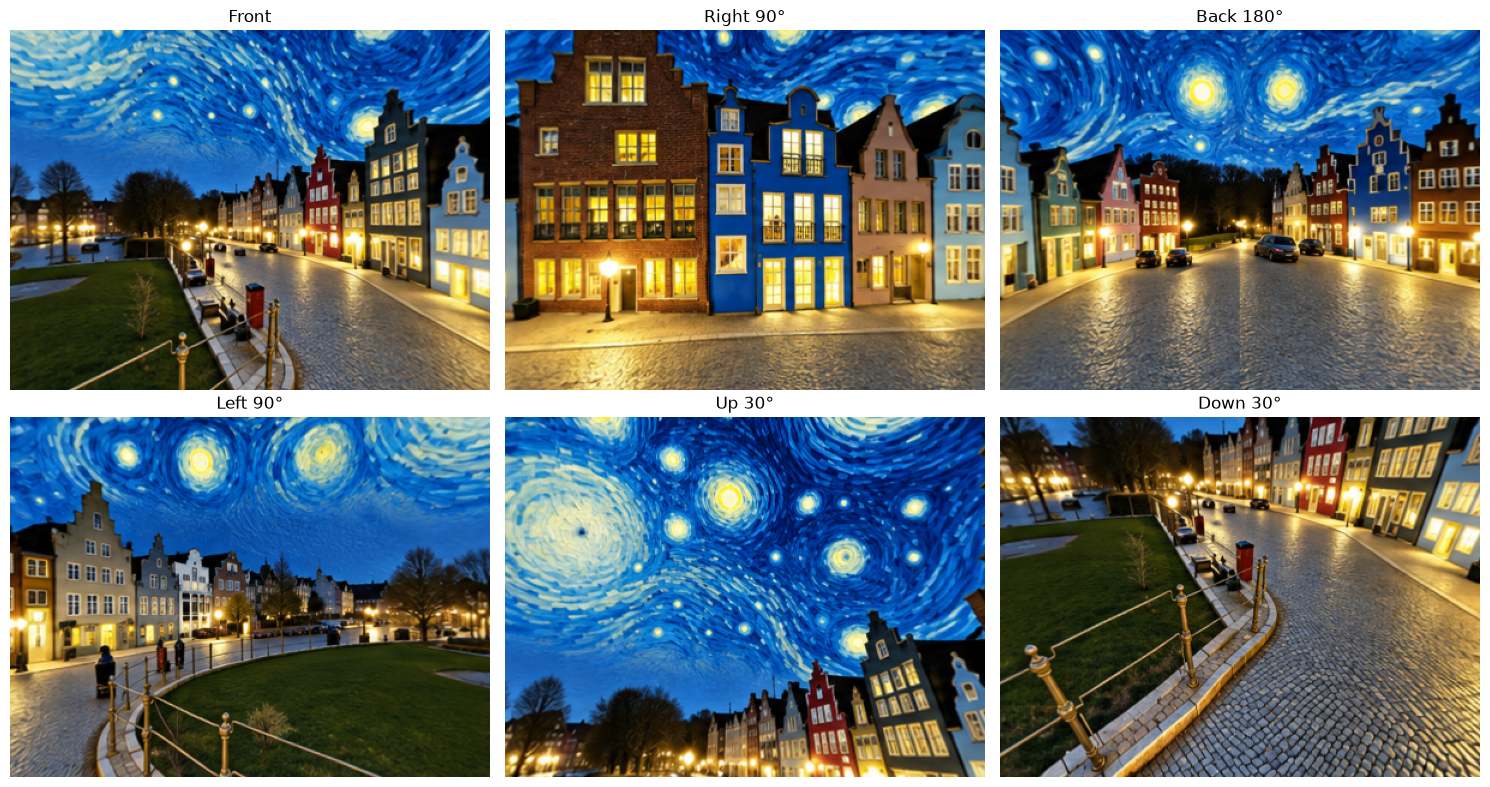

In [14]:
configs = [
    ("Front", 0, 0),
    ("Right 90°", 90, 0),
    ("Back 180°", 180, 0),
    ("Left 90°", -90, 0),
    ("Up 30°", 0, 30),
    ("Down 30°", 0, -30),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (name, yaw, pitch) in zip(axes.ravel(), configs):
    view, _, _ = erp_to_perspective(
        pano,
        out_w=400,
        out_h=300,
        fov_deg=90,
        yaw_deg=yaw,
        pitch_deg=pitch,
    )
    ax.imshow(np.clip(view, 0, 1))
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Camera origin과 Plücker moment 비교

같은 direction이라도 origin이 바뀌면 $m$이 달라집니다.

예제의 $d=(0,0,1)$에 대해 $o=(1,0,0)$이면 $m=o\times d=(0,-1,0)$입니다. 현재 sampling은 $d$만 사용하므로 origin을 바꿔도 출력 영상은 달라지지 않습니다.

In [16]:
center_ray = np.array([[[0.0, 0.0, 1.0]]], dtype=np.float32)

e0, m0, d0 = plucker_rays(center_ray, camera_origin=(0,0,0))
e1, m1, d1 = plucker_rays(center_ray, camera_origin=(1,0,0))

print("Origin=(0,0,0)")
print("d =", d0[0,0])
print("m =", m0[0,0])
print("e =", e0[0,0])

print("\nOrigin=(1,0,0)")
print("d =", d1[0,0])
print("m =", m1[0,0])
print("e =", e1[0,0])

Origin=(0,0,0)
d = [0. 0. 1.]
m = [0. 0. 0.]
e = [0. 0. 0. 0. 0. 1.]

Origin=(1,0,0)
d = [0. 0. 1.]
m = [ 0. -1.  0.]
e = [ 0. -1.  0.  0.  0.  1.]


## 12. Discussion

1. 왜 ERP sampling에는 Plücker vector 6차원 중 $d$만 사용되는가?

Plucker ray는 e = (m, d)로 표현되며, 여기서 d는 ray가 향하는 방향을 나타내고 m = o x d는 같은 방향을 가진 여러 ray 중에서 해당 ray의 공간적 위치를 구분하는 역할을 한다. 즉, d는 viewing direction에 해당하고 m은 ray가 공간에서 어떤 직선에 해당하는지를 나타낸다.
ERP panorama는 하나의 고정된 camera center에서 각 방향에 대한 색 정보를 저장하므로 ERP sampling에서 실제로 필요한 정보는 ray가 어느 방향을 향하고 있는지에 대한 정보이다. Perspective image의 각 pixel에서 계산된 ray direction d를 이용하면 longitude와 latitude를 구할 수 있고, 이를 다시 ERP의 pixel coordinate로 변환하여 sampling 위치를 결정할 수 있다. 따라서 이 과정에서는 ray의 공간적 위치를 나타내는 m은 필요하지 않고 방향을 나타내는 d만 사용하면 된다.
 

2. camera origin을 바꾸면 $m$은 바뀌는데, 이 notebook의 결과 영상은 왜 바뀌지 않는가?

Plucker representation에서 m = o x d로 정의되기 때문에 camera origin인 o가 변하면 m의 값도 변하게 된다. 그러나 현재 notebook에서 ERP image를 sampling할 때는 Plucker vector 전체를 사용하는 것이 아니라 ray direction d만 사용한다. 따라서 camera origin을 이동시켜 m의 값이 달라지더라도 d가 동일하면 ERP에서 선택되는 pixel의 위치는 변하지 않는다.
즉, camera origin이 변하면 같은 direction을 갖는 ray라도 공간에서는 서로 다른 직선을 나타내므로 Plucker moment m은 달라진다. 하지만 현재 구현에서는 이 정보가 실제 sampling 과정에 사용되지 않는다. 따라서 동일한 direction d를 사용하면 동일한 longitude와 latitude가 계산되고, 결과적으로 출력되는 perspective image도 그대로 유지된다.

3. translation에 따른 실제 parallax를 만들려면 무엇이 추가로 필요한가?

Camera translation에 따른 실제 parallax를 표현하기 위해서는 각 pixel에 대응하는 depth 정보 또는 3D scene geometry가 추가로 필요하다. 현재 ERP image에서는 각 pixel이 어느 방향을 바라보고 있는지는 알 수 있지만, 그 방향에 존재하는 물체가 camera로부터 얼마나 떨어져 있는지는 알 수 없다.
Parallax는 camera가 이동했을 때 가까운 물체와 먼 물체가 영상에서 서로 다른 양만큼 이동해 보이는 현상이다. 따라서 ray direction만으로는 이러한 차이를 계산할 수 없다. 각 pixel의 depth인 D(u, v)를 알고 있다면 ray direction인 d(u, v)와 결합하여 X = C + D(u, v)d(u, v)와 같이 실제 3D point를 구성할 수 있다. 이후 camera 위치를 이동한 뒤 해당 3D point를 새로운 camera viewpoint로 다시 projection하면 translation에 따른 parallax를 표현할 수 있다.
강의자료에서도 panorama의 각 ray에 depth를 곱해 Gaussian의 초기 3D 위치를 계산하는 방식이 설명되어 있다. 따라서 실제 translation에 따른 parallax를 표현하려면 depth map 또는 이에 해당하는 3D scene geometry가 필요하다.

4. yaw=30°, pitch=20°, roll=10°를 동시에 적용한다. 회전행렬의 곱 순서를 Ry @ Rx(-pitch) @ Rz와 Rz @ Rx(-pitch) @ Ry로 각각 구성하여 출력 영상을 비교하고, 결과가 달라지는 이유를 설명하시오.

Ry @ Rx(-pitch) @ Rz:
 [[ 0.823173 -0.318796  0.469846]
 [ 0.163176  0.925417  0.34202 ]
 [-0.543838 -0.204874  0.813798]]
Rz @ Rx(-pitch) @ Ry:
 [[ 0.882564 -0.163176  0.44097 ]
 [-0.018028  0.925417  0.378522]
 [-0.469846 -0.34202   0.813798]]


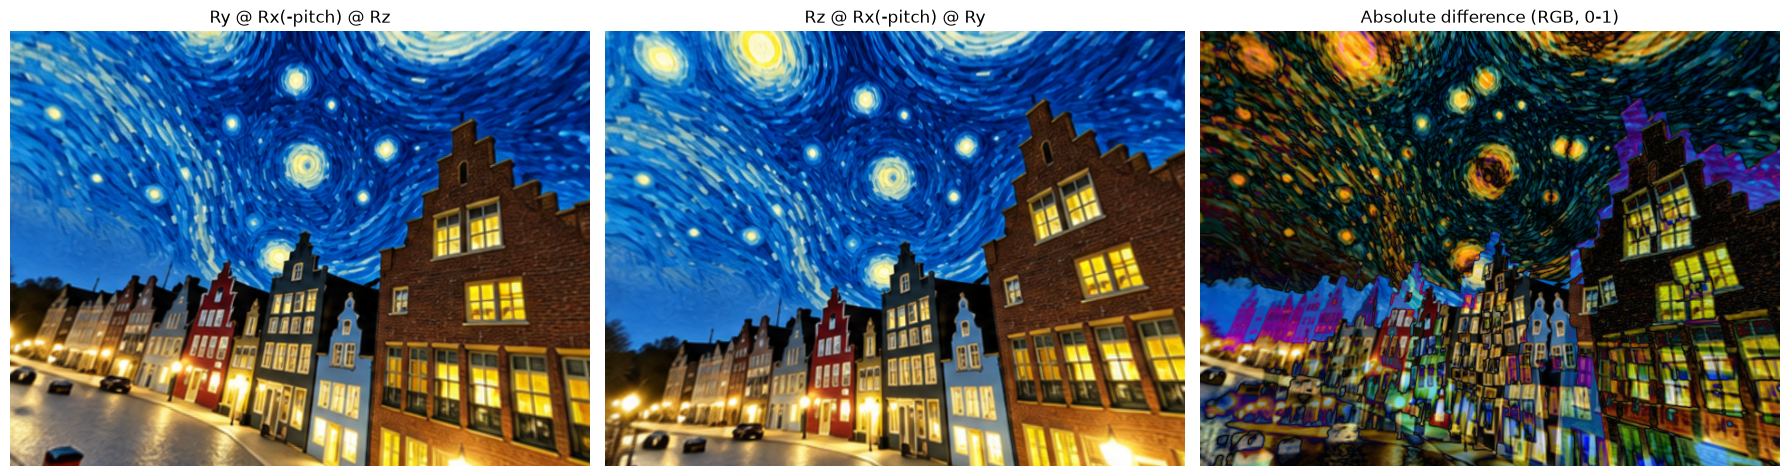

In [ ]:
# 파노라마, 출력 크기, 수평 FOV, 카메라 위치, 보간 방식은 동일하게 유지
d4_out_w, d4_out_h, d4_fov = 640, 480, 90
d4_origin = (0.0, 0.0, 0.0)
d4_yaw_deg, d4_pitch_deg, d4_roll_deg = 30, 20, 10
# 양수 yaw는 오른쪽을 의미
# 양수 pitch는 위쪽을 의미
# 회전 함수에 넣을 각도는 라디안으로 변환
d4_yaw, d4_pitch, d4_roll = np.deg2rad(
    [d4_yaw_deg, d4_pitch_deg, d4_roll_deg]
)

R_order1 = Ry(d4_yaw) @ Rx(-d4_pitch) @ Rz(d4_roll)
R_order2 = Rz(d4_roll) @ Rx(-d4_pitch) @ Ry(d4_yaw)
print("Ry @ Rx(-pitch) @ Rz:\n", 
      np.array2string(R_order1, precision=6))
print("Rz @ Rx(-pitch) @ Ry:\n",
      np.array2string(R_order2, precision=6))

# 첫 번째 회전 순서는 기존 변환 함수를 그대로 사용
d4_view1, _, _ = erp_to_perspective(
    pano, out_w=d4_out_w, out_h=d4_out_h, fov_deg=d4_fov, yaw_deg=d4_yaw_deg, pitch_deg=d4_pitch_deg, roll_deg=d4_roll_deg, camera_origin=d4_origin,
)

# 회전 순서를 바꿔 비교하기 위해 R을 직접 받는 함수
def d4_render_with_rotation(panorama, rotation, out_w, out_h, fov_deg, origin):
    camera_rays = perspective_camera_rays(out_w, out_h, fov_deg)
    world_rays = rotate_rays(camera_rays, rotation)
    _, _, directions = plucker_rays(world_rays, camera_origin=origin)
    erp_h, erp_w = panorama.shape[0:2]
    sample_u, sample_v = direction_to_erp_uv(directions, erp_w, erp_h)
    return bilinear_sample_erp(panorama, sample_u, sample_v)

d4_view2 = d4_render_with_rotation(
    pano, R_order2, d4_out_w, d4_out_h, d4_fov, d4_origin,
)
# 두 영상의 RGB 값 차이를 절댓값으로 구함
# 밝기는 원래의 0~1 범위를 그대로 사용
d4_difference = np.abs(d4_view1 - d4_view2)
d4_fig, d4_axes = plt.subplots(1, 3, figsize=(18, 5))
for d4_ax, d4_image, d4_title in zip(
    d4_axes,
    [d4_view1, d4_view2, d4_difference],
    ["Ry @ Rx(-pitch) @ Rz", "Rz @ Rx(-pitch) @ Ry",
     "Absolute difference (RGB, 0-1)"],
):
    d4_ax.imshow(np.clip(d4_image, 0, 1))
    d4_ax.set_title(d4_title)
    d4_ax.axis("off")
d4_fig.tight_layout()
plt.show()


![alt text](discussion4-1.png)

Yaw, pitch, roll을 동시에 적용할 때 R_yR_xR_z와 R_zR_xR_y는 일반적으로 서로 다른 결과를 만든다. 그 이유는 3차원 rotation matrix의 곱셈에서는 교환법칙이 성립하지 않기 때문이다. 즉, R_yR_xR_z 와 R_zR_xR_y는 같지 않다.
Column vector를 기준으로 행렬을 적용하면 오른쪽에 있는 rotation부터 먼저 적용되기 때문에 R_yR_xR_z와 R_zR_xR_y는 실제 회전이 적용되는 순서가 서로 다르다. 첫 번째 회전을 적용한 결과에 다음 회전이 연속적으로 적용되므로 회전 순서가 달라지면 각 단계에서 회전되는 중간 방향이 달라진다. 따라서 동일한 yaw, pitch, roll 값을 사용하더라도 최종 camera orientation은 달라진다. 강의 자료에서도 Euler angle을 이용한 3차원 rotation에서 rotation order에 주의해야 함을 강조하고 있다.
따라서 yaw 30도, pitch 20도, roll 10도를 동일하게 사용하더라도 rotation matrix의 곱 순서를 다르게 하면 최종 ray direction이 달라지고 ERP에서 sampling되는 영역도 달라져, 서로 다른 perspective image가 생성된다.
실제 결과에서도 두 영상은 중심으로 보이는 영역과 화면의 기울어진 방향에서 차이가 나타났다. 첫 번째 R_y @ R_x(-pitch) @ R_z 결과에서는 오른쪽의 갈색 건물이 화면 가장자리에 크게 위치하고, 하늘의 큰 소용돌이 무늬가 화면 중앙 위쪽에 나타난다. 반면 두 번째 R_z @ R_x(-pitch) @ R_y 결과에서는 전체 장면이 첫 번째 결과에 비해 회전된 형태로 나타나며, 하늘의 별과 소용돌이 및 건물들의 위치가 함께 이동하였다. 특히 건물의 수직선과 지평선의 기울기가 서로 다름을 확인할 수 있다. 오른쪽의 absolute difference 영상에서도 하늘, 건물, 도로를 포함한 영상 전반에 큰 차이가 나타나므로, 단순히 일부 영역만 이동한 것이 아니라 전체 viewing direction이 달라졌음을 확인할 수 있다. 이는 3차원 회전에서 각 회전이 적용되는 순서에 따라 이후 회전의 기준 방향이 달라지기 때문이다. 따라서 동일한 yaw, pitch, roll 값을 사용하더라도 회전행렬의 곱 순서가 달라지면 최종 camera orientation과 ERP에서 sampling되는 영역이 달라진다.


5. 출력 FOV를 $60^\circ$와 $120^\circ$로 바꾸었을 때 결과 영상의 왜곡과 포함되는 장면 범위가 어떻게 달라지는지 설명하시오.

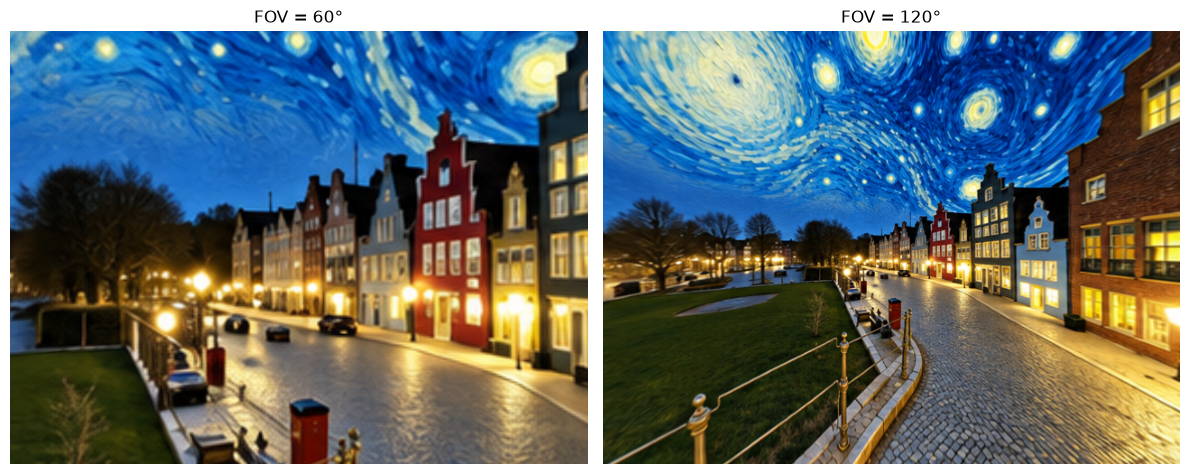

In [ ]:
# 같은 파노라마를 정면에서 보고
# 출력 크기와 카메라 위치, sampling 방식을 고정한 채 FOV만 변경
d5_out_w, d5_out_h = 640, 480
d5_views = []
# 나머지 조건은 고정하고 FOV 60도와 120도를 비교
for d5_fov in [60, 120]:
    d5_view, _, _ = erp_to_perspective(
        pano, out_w=d5_out_w, out_h=d5_out_h, fov_deg=d5_fov, yaw_deg=0, pitch_deg=0, roll_deg=0, camera_origin=(0.0, 0.0, 0.0),
    )
    
    d5_views.append(d5_view)

d5_fig, d5_axes = plt.subplots(1, 2, figsize=(12, 5))
for d5_ax, d5_image, d5_title in zip(
    d5_axes, d5_views, ["FOV = 60°", "FOV = 120°"],
):
    d5_ax.imshow(np.clip(d5_image, 0, 1))
    d5_ax.set_title(d5_title)
    d5_ax.axis("off")
d5_fig.tight_layout()
plt.show()


![alt text](discussion5-1.png)

FOV는 하나의 perspective image가 포함하는 시야의 각도 범위를 의미한다. FOV를 60도로 설정하면 비교적 좁은 범위의 장면만 영상에 포함되므로 중앙 영역이 크게 보이고, 물체 역시 상대적으로 크게 나타난다. 또한 FOV가 작을수록 광축에서 크게 벗어난 방향의 ray가 적게 포함되므로 화면 가장자리의 perspective distortion도 비교적 작다. FOV를 120도로 증가시키면 훨씬 넓은 범위의 장면을 한 화면에 포함할 수 있다. 하지만 동일한 출력 image size에 더 넓은 angular range를 투영해야 하므로 각 물체는 상대적으로 작아지고, 화면 가장자리로 갈수록 물체의 형태가 크게 늘어나 보이는 왜곡이 나타난다. Pinhole camera model에서 FOV가 증가한다는 것은 더 넓은 방향의 ray들을 하나의 image plane에 투영하는 것과 같기 때문이다.
실제 결과에서도 이러한 차이를 확인할 수 있었다. FOV가 60도일 때는 중앙의 도로와 건물들이 화면의 대부분을 차지하고 건물도 비교적 크게 보였다. 반면 FOV를 120도로 증가시키면 왼쪽의 잔디 공간과 위쪽의 하늘이 더 많이 포함되고, 기존에는 보이지 않던 오른쪽의 파란색 건물과 갈색 건물까지 나타나 전체적으로 훨씬 넓은 장면을 확인할 수 있었다. 대신 중앙의 건물들은 상대적으로 작게 보였으며, 좌측 난간과 우측 건물처럼 화면 가장자리에 위치한 물체는 바깥쪽으로 갈수록 더 크게 늘어나 보였다. 따라서 FOV를 크게 설정하면 넓은 시야를 확보할 수 있지만, 그만큼 화면 가장자리의 perspective distortion이 증가하는 trade-off가 존재한다.